# Exploração da demanda de bicicletas compartilhadas em Seul com SOM

**Integrantes da equipe:** Gabriel Albuquerque Alencar, Alberto Eduardo Acosta, Davi Maciel Corrêa

**Disciplina:** Inteligência Computacional / Machine Learning — Profa. Polyana Santos Fonseca Nascimento

## Declaração de uso de IA Generativa

- **Ferramenta utilizada:** Claude (Anthropic), via Claude Code.
- **Finalidade do uso:** apoio na escrita do código e da documentação em Markdown deste notebook: adaptação do pré-processamento para a SOM, configuração e treinamento do mapa, visualizações (U-Matrix, Hit Map, mapas de componentes, alvo e erros da MLP por neurônio), delimitação das regiões e redação das interpretações.
- **Extensão aproximada da contribuição:** a IA gerou a maior parte do código e dos textos, a partir das decisões e do pré-processamento já definidos pela equipe no trabalho de MLP. As escolhas de configuração e as interpretações devem ser compreendidas e defendidas por cada integrante.
- **Medidas de validação:** o notebook é executado de ponta a ponta com sementes fixas; a MLP final é reproduzida aqui e uma verificação automática (`assert`) confirma que as métricas de teste são as mesmas do notebook de MLP; cada interpretação de região é conferida com contagens e estatísticas descritivas das observações associadas aos BMUs; os resultados e gráficos são revisados pela equipe.

> Este notebook complementa `mlp_seoul_bike.ipynb` e usa o mesmo arquivo de entrada, `SeoulBikeData_treated.csv`, gerado por `preprocessing.ipynb`. A contextualização do dataset e a análise exploratória completa estão no notebook de MLP e não são repetidas aqui.

## 1. Dataset e objetivo da SOM

- **Dataset:** o mesmo do trabalho de MLP, *Seoul Bike Sharing Demand* (UCI / Kaggle): 8.465 registros horários de dez/2017 a nov/2018, já sem as horas em que o sistema estava fechado.
- **Problema original:** regressão de `Rented Bike Count` (bicicletas alugadas por hora).
- **Papel da SOM:** análise exploratória não supervisionada. O mapa é treinado **somente com as condições da hora** (clima, hora do dia e fim de semana), sem ver a demanda. Depois, a demanda e os erros da MLP são projetados sobre o mapa para responder: *quais tipos de hora existem no dataset, como a demanda se distribui entre eles e onde a MLP erra mais?*

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["PYTHONWARNINGS"] = "ignore"

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from minisom import MiniSom
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

SEED = 42
TARGET = "Rented Bike Count"
DATA_PATH = "SeoulBikeData_treated.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
print(df.shape)

(8465, 14)


## 2. Preparação dos dados

### 2.1 O que é reaproveitado do trabalho de MLP

- Mesmo arquivo tratado (sem `Functioning Day = No`, com `IsWeekend`).
- `Dew point temperature` continua fora (correlação 0,91 com `Temperature`).
- `Hour` continua codificada como `sin`/`cos`, para que 23h fique vizinha de 0h também no mapa.
- Os atributos continuam padronizados com `StandardScaler`. Na SOM isso é ainda mais importante que na MLP: o BMU é escolhido por **distância euclidiana**, e sem padronização a visibilidade (na casa dos milhares) decidiria sozinha o mapa.

### 2.2 O que muda em relação à MLP

| Alteração | Motivo |
|---|---|
| `Rented Bike Count` **fora** das entradas | exigência do aprendizado não supervisionado; o alvo só é projetado no mapa depois do treino |
| `log1p` em `Rainfall` e `Snowfall` antes da padronização | a MLP aprende pesos e absorve valores extremos; na SOM, uma hora com 35 mm de chuva ficaria a ~31 desvios padrão da média e dominaria a distância, puxando protótipos só para ela |
| `Seasons` e `Holiday` **fora** das entradas, usados só na interpretação | o *one-hot* de `Seasons` criaria 4 dimensões binárias que partiriam o mapa em ilhas por rótulo de calendário, e a temperatura já carrega a informação sazonal (tabela abaixo). `Holiday` ocorre em ~5% das horas: como binária rara, geraria um grupo isolado sem estrutura climática. Projetá-los depois permite verificar **se** o mapa recupera a sazonalidade sozinho |
| Padronização ajustada em **todas** as 8.465 horas | a SOM não usa o alvo e não alimenta a MLP; é uma ferramenta de EDA sobre o dataset inteiro. O holdout da MLP é respeitado na seção 6, onde os erros de cada hora vêm de modelos que não a viram no treino |

In [2]:
NUMERIC = ["Temperature(°C)", "Humidity(%)", "Wind speed (m/s)", "Visibility (10m)",
           "Solar Radiation (MJ/m2)", "Rainfall(mm)", "Snowfall (cm)"]
SKEWED = ["Rainfall(mm)", "Snowfall (cm)"]


def max_z(s):
    return float(((s - s.mean()) / s.std()).abs().max())


pd.DataFrame({
    "% zeros": (df[SKEWED] == 0).mean().mul(100),
    "máximo": df[SKEWED].max(),
    "maior |z| original": df[SKEWED].apply(max_z),
    "maior |z| após log1p": np.log1p(df[SKEWED]).apply(max_z),
}).round(1)

,% zeros,máximo,maior |z| original,maior |z| após log1p
Rainfall(mm),93.9,35.0,31.0,12.6
Snowfall (cm),94.8,8.8,19.6,10.9


In [3]:
df.groupby("Seasons")["Temperature(°C)"].describe()[["mean", "std", "min", "max"]].loc[["Winter", "Spring", "Summer", "Autumn"]].round(1)

,mean,std,min,max
Seasons,,,,
Winter,-2.5,5.5,-17.8,10.3
Spring,13.0,6.7,-6.6,29.4
Summer,26.6,4.7,16.3,39.4
Autumn,13.8,7.2,-3.0,30.5


- **Chuva e neve:** sem transformação, a hora mais chuvosa fica a 31 desvios padrão da média, e a de mais neve a 20. Com `log1p` esses valores caem para 12,6 e 10,9. Continuam extremos (são eventos raros de verdade e devem ficar separados no mapa), mas deixam de dominar a distância euclidiana.
- **Estação:** a temperatura média vai de −2,5 °C no inverno a 26,6 °C no verão, então inverno e verão já são separados pela temperatura. Primavera e outono têm temperaturas quase iguais (13,0 e 13,8 °C): se o mapa não as separar, isso é um achado sobre os dados, não uma falha da preparação.

In [4]:
def build_som_inputs(data):
    X = data[NUMERIC].copy()
    X[SKEWED] = np.log1p(X[SKEWED])
    X["hour_sin"] = np.sin(2 * np.pi * data["Hour"] / 24)
    X["hour_cos"] = np.cos(2 * np.pi * data["Hour"] / 24)
    X["IsWeekend"] = data["IsWeekend"]
    return X


from sklearn.preprocessing import StandardScaler

X_som = build_som_inputs(df)
INPUTS = X_som.columns.tolist()
scaler = StandardScaler().fit(X_som)
Z = scaler.transform(X_som)
print("Entradas da SOM:", len(INPUTS))
print(INPUTS)
print("Matriz de treino:", Z.shape)

Entradas da SOM: 10
['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'hour_sin', 'hour_cos', 'IsWeekend']
Matriz de treino: (8465, 10)


## 3. Configuração e treinamento da SOM

### 3.1 Dimensões da malha

Usamos duas regras práticas da literatura (Vesanto, *SOM Toolbox*):

- **número de neurônios ≈ 5·√N**, com N = 8.465 horas;
- **razão entre os lados ≈ √(λ₁/λ₂)**, a raiz da razão entre os dois maiores autovalores da PCA dos dados padronizados, para que o mapa se estique na direção de maior variância.

In [5]:
from sklearn.decomposition import PCA

eigvals = PCA().fit(Z).explained_variance_
n_target = 5 * np.sqrt(len(Z))
side_ratio = np.sqrt(eigvals[0] / eigvals[1])
print(f"5·√N = {n_target:.0f} neurônios | √(λ1/λ2) = {side_ratio:.2f}")
print("Autovalores da PCA:", eigvals.round(2))

5·√N = 460 neurônios | √(λ1/λ2) = 1.30
Autovalores da PCA: [2.6  1.53 1.25 1.14 1.   0.8  0.69 0.55 0.28 0.17]


Uma malha **24 × 18** tem 432 neurônios (próximo de 460) e razão 1,33 (próxima de 1,30).

### 3.2 Hiperparâmetros

| Hiperparâmetro | Valor | Justificativa |
|---|---|---|
| malha | 24 × 18, retangular | regras acima; vizinhança de 8 neurônios, a mesma usada no erro topográfico do MiniSom |
| inicialização | PCA (`pca_weights_init`) | o mapa começa esticado no plano dos dois primeiros componentes, o que acelera a ordenação e torna o resultado determinístico |
| iterações | 10 × N = 84.650 | cada hora é apresentada ~10 vezes, em ordem aleatória |
| `sigma` inicial | 3,0 (decai até 1,0) | raio de vizinhança gaussiano: grande no início para ordenar o mapa, ~1 neurônio no fim para refinar |
| taxa de aprendizagem | 0,5 (decai até ~0,17) | valor padrão do MiniSom; o decaimento assintótico reduz os dois parâmetros a 1/3 do valor inicial |

Não fazemos busca exaustiva. Apenas conferimos o efeito de `sigma`, o parâmetro que controla diretamente o compromisso entre os dois erros: `sigma` pequeno ajusta cada neurônio aos seus dados (erro de quantização baixo), mas pode dobrar o mapa (erro topográfico alto).

In [6]:
MAP_X, MAP_Y = 24, 18
N_ITER = 10 * len(Z)
LEARNING_RATE = 0.5


def train_som(sigma):
    som = MiniSom(MAP_X, MAP_Y, Z.shape[1], sigma=sigma, learning_rate=LEARNING_RATE,
                  neighborhood_function="gaussian", topology="rectangular",
                  activation_distance="euclidean", random_seed=SEED)
    som.pca_weights_init(Z)
    som.train(Z, N_ITER, random_order=True)
    return som


sigma_check = {}
for s in [1.0, 2.0, 3.0, 4.0]:
    m = train_som(s)
    sigma_check[s] = {"erro de quantização": m.quantization_error(Z),
                      "erro topográfico": m.topographic_error(Z),
                      "neurônios vazios": int((m.activation_response(Z) == 0).sum())}
pd.DataFrame(sigma_check).T.rename_axis("sigma inicial").round(3)

,erro de quantização,erro topográfico,neurônios vazios
sigma inicial,,,
1.0,0.812,0.431,12.0
2.0,0.969,0.119,9.0
3.0,1.098,0.047,13.0
4.0,1.233,0.032,24.0


O resultado confirma o compromisso esperado:

- `sigma = 1` tem o menor erro de quantização (0,81), mas **43%** das horas têm os dois melhores neurônios não vizinhos: o mapa se dobrou e perdeu a topologia, o que invalida a leitura da U-Matrix.
- `sigma = 2` ainda tem 12% de erro topográfico.
- `sigma = 3` reduz o erro topográfico para **4,7%** com erro de quantização de 1,10.
- `sigma = 4` ganha pouco em topologia (3,2%), aumenta o erro de quantização (1,23) e quase dobra os neurônios vazios (24), sinal de protótipos alisados demais.

**Decisão:** `sigma = 3`, o menor valor que preserva bem a topologia.

In [7]:
SIGMA = 3.0
som = train_som(SIGMA)

qe = som.quantization_error(Z)
te = som.topographic_error(Z)
dist_to_centroid = np.linalg.norm(Z - Z.mean(axis=0), axis=1).mean()
print(f"Erro de quantização: {qe:.3f}")
print(f"Erro topográfico:    {te:.3f} ({te:.1%} das horas)")
print(f"Referência: distância média de uma hora ao centróide dos dados = {dist_to_centroid:.3f}")

Erro de quantização: 1.098
Erro topográfico:    0.047 (4.7% das horas)
Referência: distância média de uma hora ao centróide dos dados = 2.987


- **Erro de quantização (1,10):** distância euclidiana média, no espaço padronizado de 10 dimensões, entre cada hora e o protótipo do seu BMU. Uma hora está em média a 2,99 do centróide dos dados, então os protótipos representam as horas cerca de **2,7 vezes melhor** que um único ponto médio. Isso equivale a cerca de 0,35 desvio padrão por atributo (1,10/√10).
- **Erro topográfico (4,7%):** em apenas 4,7% das horas o segundo melhor neurônio não é vizinho do primeiro. O mapa preserva a vizinhança dos dados: horas parecidas ficam em neurônios próximos, então faz sentido ler regiões contíguas do mapa.

## 4. Visualizações

Cada hora é associada ao seu BMU (*best matching unit*), o neurônio cujo protótipo está mais próximo dela. Todas as figuras usam a mesma orientação: o eixo horizontal é a primeira dimensão da malha (24 neurônios) e o vertical a segunda (18). Neurônios sem nenhuma hora aparecem em cinza.

In [8]:
bmus = np.array([som.winner(z) for z in Z])
df_map = df.assign(bmu_x=bmus[:, 0], bmu_y=bmus[:, 1])
hits = som.activation_response(Z)


def per_neuron(values, stat="mean", min_hits=1):
    # Estatística de uma coluna por neurônio, como matriz MAP_X × MAP_Y (NaN onde há menos de min_hits horas).
    g = pd.Series(np.asarray(values), index=pd.MultiIndex.from_arrays([bmus[:, 0], bmus[:, 1]])).groupby(level=[0, 1])
    agg, n = g.agg(stat), g.size()
    grid = np.full((MAP_X, MAP_Y), np.nan)
    for (i, j), v in agg[n >= min_hits].items():
        grid[i, j] = v
    return grid


def plot_map(values, ax, title, cmap="viridis", label=None, **kwargs):
    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad("lightgray")
    mesh = ax.pcolormesh(np.ma.masked_invalid(values).T, cmap=cmap, **kwargs)
    ax.set(title=title, xticks=[], yticks=[], aspect="equal")
    ax.grid(False)
    plt.colorbar(mesh, ax=ax, label=label, fraction=0.035, pad=0.02)
    return mesh

### 4.1 U-Matrix e Hit Map

- **U-Matrix:** distância média de cada protótipo aos vizinhos. Valores **altos** (claros) são fronteiras entre grupos de horas diferentes. Valores baixos (escuros) são regiões homogêneas.
- **Hit Map:** quantas horas têm cada neurônio como BMU. Mostra onde os dados se concentram e quais neurônios estão pouco ocupados.

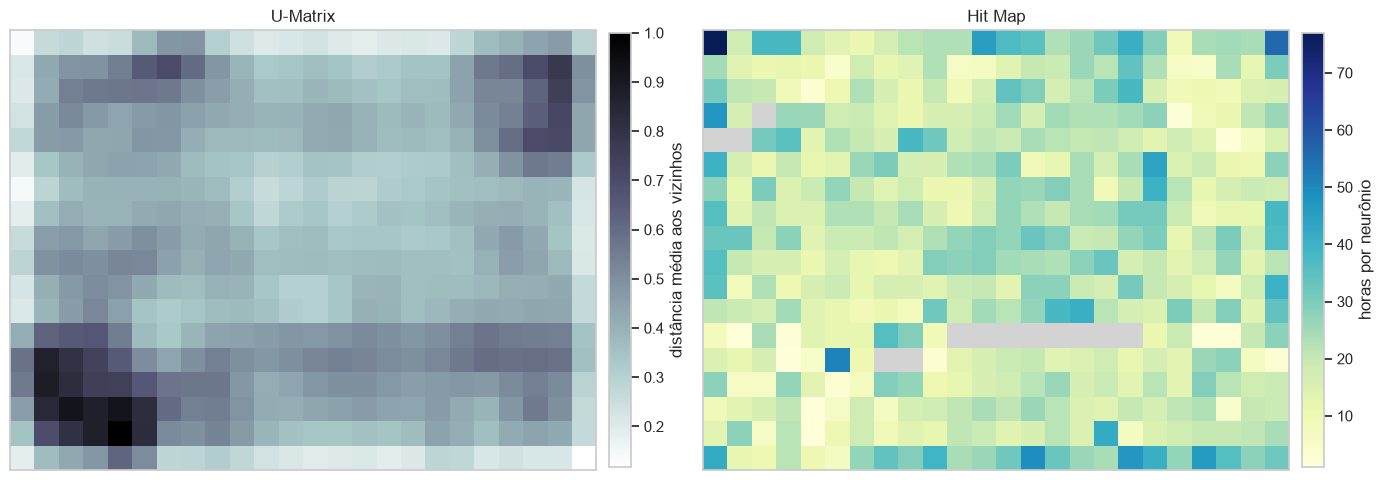

Horas por neurônio: mediana 19, máximo 77
Neurônios vazios: 13 | com menos de 5 horas: 28 de 432


In [9]:
umatrix = som.distance_map()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_map(umatrix, axes[0], "U-Matrix", cmap="bone_r", label="distância média aos vizinhos")
plot_map(np.where(hits > 0, hits, np.nan), axes[1], "Hit Map", cmap="YlGnBu", label="horas por neurônio")
plt.tight_layout()
plt.show()

print(f"Horas por neurônio: mediana {np.median(hits):.0f}, máximo {hits.max():.0f}")
print(f"Neurônios vazios: {(hits == 0).sum()} | com menos de 5 horas: {(hits < 5).sum()} de {hits.size}")

**Leitura da U-Matrix.** A maior parte do mapa tem distâncias baixas e graduais, ou seja, as horas formam um **contínuo** e não grupos isolados. Há três estruturas nítidas:

1. **canto inferior esquerdo:** a crista mais escura do mapa, um grupo pequeno e muito diferente dos vizinhos;
2. **canto superior direito:** outra crista forte, também em um grupo pequeno;
3. **uma faixa horizontal no terço inferior**, que atravessa o mapa de ponta a ponta e separa a parte de baixo do restante.

**Leitura do Hit Map.** A ocupação é relativamente uniforme (mediana de 19 horas por neurônio, máximo de 77), então o mapa usa bem os 432 neurônios. Os 13 neurônios vazios não estão espalhados: formam uma linha justamente sobre a faixa horizontal da U-Matrix. São neurônios de "interpolação" entre dois grupos, cujos protótipos ficam no meio do caminho e não representam nenhuma hora real. Os mapas de componentes a seguir mostram o que cada estrutura significa.

### 4.2 Mapas de componentes

Valor de cada atributo no protótipo de cada neurônio, **na escala original** (a padronização e o `log1p` são desfeitos). Comparar um mapa de componente com a U-Matrix mostra quais atributos formam cada fronteira.

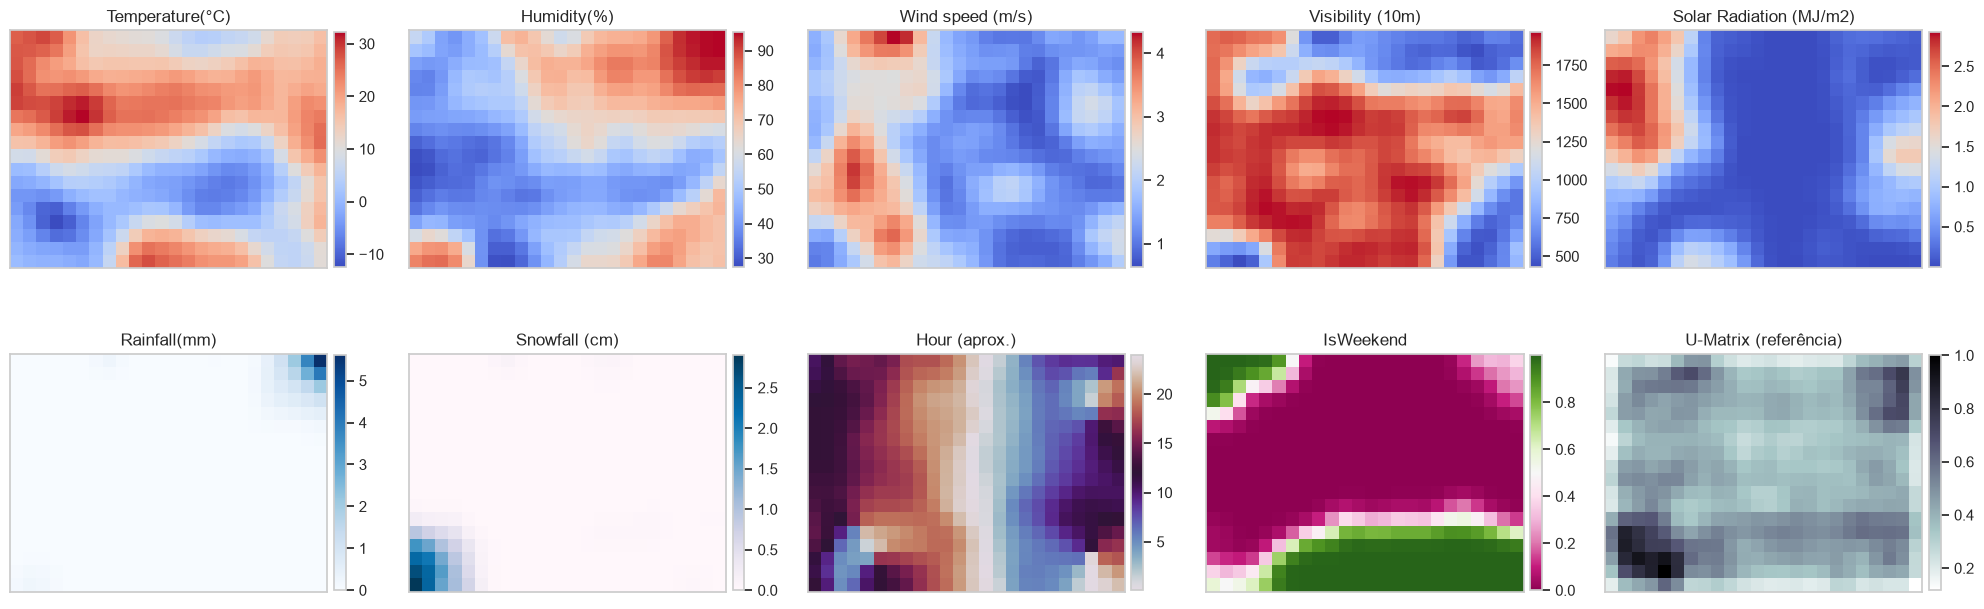

In [10]:
codebook = som.get_weights().reshape(-1, len(INPUTS))
proto = pd.DataFrame(scaler.inverse_transform(codebook), columns=INPUTS)
proto[SKEWED] = np.expm1(proto[SKEWED])
proto["Hour (aprox.)"] = (np.degrees(np.arctan2(proto["hour_sin"], proto["hour_cos"])) % 360) / 15

COMPONENTS = ["Temperature(°C)", "Humidity(%)", "Wind speed (m/s)", "Visibility (10m)", "Solar Radiation (MJ/m2)",
              "Rainfall(mm)", "Snowfall (cm)", "Hour (aprox.)", "IsWeekend"]
CMAPS = {"Hour (aprox.)": "twilight", "Rainfall(mm)": "Blues", "Snowfall (cm)": "PuBu", "IsWeekend": "PiYG"}

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.flat, COMPONENTS):
    plot_map(proto[col].to_numpy().reshape(MAP_X, MAP_Y), ax, col, cmap=CMAPS.get(col, "coolwarm"))
plot_map(umatrix, axes.flat[-1], "U-Matrix (referência)", cmap="bone_r")
plt.tight_layout()
plt.show()

`Hour (aprox.)` é a hora recuperada do par `sin`/`cos` do protótipo, com escala circular (0h e 24h têm a mesma cor).

Comparando com a U-Matrix:

- **Canto superior direito = chuva.** `Rainfall` só é alto ali, junto com umidade máxima (>90%) e visibilidade baixa.
- **Canto inferior esquerdo = neve.** `Snowfall` só aparece ali, com temperatura abaixo de zero e visibilidade baixa. Chuva e neve são os eventos mais raros e mais diferentes do dataset, por isso formam as cristas mais fortes.
- **Faixa horizontal = fim de semana.** `IsWeekend` é praticamente binário no mapa: a faixa de baixo contém as horas de fim de semana e a fronteira coincide com a crista da U-Matrix e com os neurônios vazios. O canto superior esquerdo também tem fins de semana, mas lá eles estão misturados a dias úteis de sol forte.
- **Temperatura** varia de cima para baixo: a metade superior é quente e o centro-inferior é frio (dias úteis de inverno, logo acima da faixa de fim de semana). Dentro da faixa de fim de semana o gradiente se repete em menor escala.
- **Hora do dia** varia na horizontal, como um relógio: na metade superior, da esquerda para a direita, aparecem meio-dia/tarde, fim de tarde e noite, madrugada e manhã.
- **Radiação solar** é alta principalmente na coluna da esquerda, que representa as horas de sol do meio do dia, e moderada na borda direita (manhãs).
- **Vento** varia pouco e em manchas, sem formar fronteiras: é o atributo que menos organiza o mapa.

### 4.3 Distribuição da variável-alvo sobre o mapa

A demanda **não** participou do treino. Projetamos agora a média e a mediana de `Rented Bike Count` das horas de cada neurônio, e também a estação e os feriados, que ficaram fora das entradas.

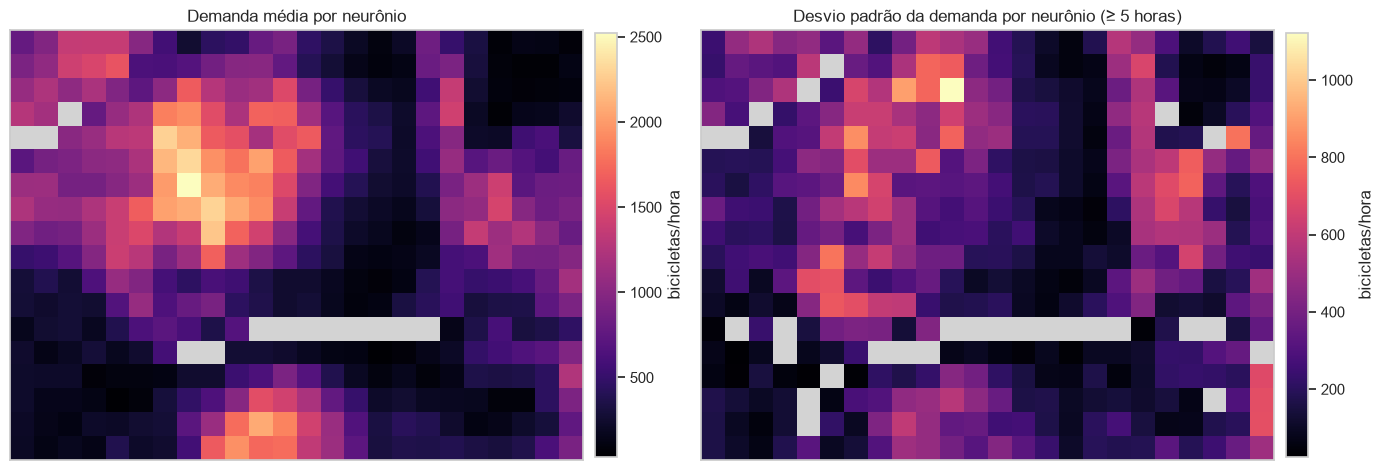

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_map(per_neuron(df[TARGET], "mean"), axes[0], "Demanda média por neurônio", cmap="magma", label="bicicletas/hora")
plot_map(per_neuron(df[TARGET], "std", min_hits=5), axes[1], "Desvio padrão da demanda por neurônio (≥ 5 horas)",
         cmap="magma", label="bicicletas/hora")
plt.tight_layout()
plt.show()

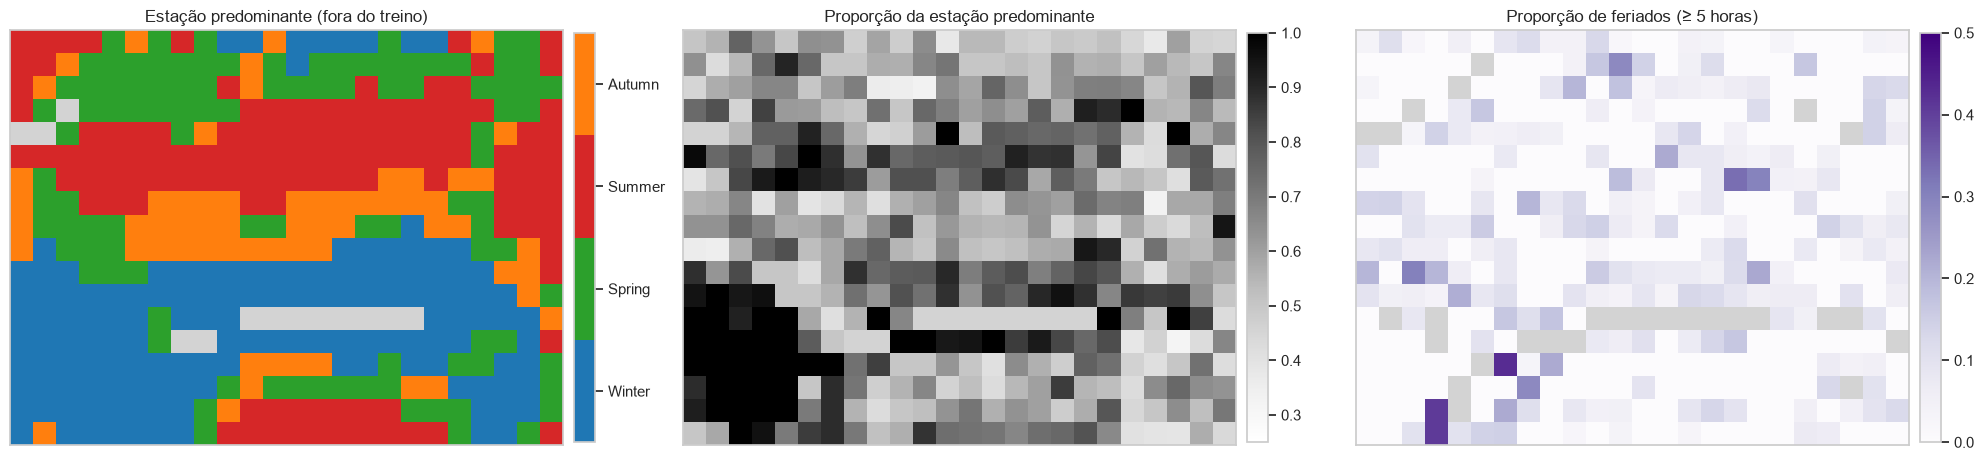

In [12]:
SEASONS = ["Winter", "Spring", "Summer", "Autumn"]
season_code = df["Seasons"].map({s: k for k, s in enumerate(SEASONS)})
dominant = per_neuron(season_code, lambda s: s.value_counts().idxmax())
purity = per_neuron(season_code, lambda s: s.value_counts(normalize=True).max())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
season_cmap = plt.matplotlib.colors.ListedColormap(["tab:blue", "tab:green", "tab:red", "tab:orange"])
mesh = plot_map(dominant, axes[0], "Estação predominante (fora do treino)", cmap=season_cmap, vmin=-0.5, vmax=3.5)
mesh.colorbar.set_ticks(range(4), labels=SEASONS)
plot_map(purity, axes[1], "Proporção da estação predominante", cmap="Greys", vmin=0.25, vmax=1)
plot_map(per_neuron(df["Holiday"].eq("Holiday").astype(float), "mean", min_hits=5), axes[2],
         "Proporção de feriados (≥ 5 horas)", cmap="Purples", vmin=0, vmax=0.5)
plt.tight_layout()
plt.show()

**Demanda média.** Mesmo sem ter visto o alvo no treino, o mapa separa claramente a demanda: há um **núcleo de alta demanda** na parte superior central (acima de 2.000 bicicletas/hora em alguns neurônios), que corresponde às horas de fim de tarde e noite quentes em dias úteis, e uma mancha secundária na faixa de fim de semana (tardes). Os cantos de chuva e neve e a região de madrugada (centro-direita) têm demanda muito baixa. Isso mostra que clima, hora e tipo de dia **já organizam a maior parte da demanda**, o que explica por que a MLP consegue R² ≈ 0,9 com esses atributos.

**Desvio padrão da demanda.** É alto justamente no núcleo de alta demanda (até ~1.000 bicicletas/hora): horas com clima, hora e tipo de dia parecidos podem ter demandas muito diferentes. Essa variação não é explicada pelas entradas da SOM e será retomada na seção 6.

**Estação e feriado, fora do treino.**

- O **inverno** ocupa a maior parte da metade inferior e tem alta pureza (neurônios pretos no mapa de proporção): o mapa recuperou o inverno sozinho, pela temperatura.
- O **verão** predomina na faixa superior e central quente.
- **Primavera e outono aparecem intercalados**, em manchas misturadas e com pureza baixa. Com clima quase igual, as duas estações são indistinguíveis nas entradas da SOM. Na MLP, `Seasons` entra como atributo explícito, e é ela que permite ao modelo diferenciá-las.
- **Feriados** não se concentram em nenhuma região (proporções baixas e espalhadas, com poucos neurônios de inverno como exceção): um feriado não tem clima nem hora próprios, então só pode ser identificado pela própria variável.

## 5. Análise integrada: localizar, caracterizar e confirmar

Para discutir regiões e não neurônios isolados, agrupamos os **protótipos** (não as horas) com agrupamento hierárquico de Ward, restrito à vizinhança da malha. A restrição garante regiões contíguas no mapa, e o Ward une primeiro os neurônios de protótipos mais parecidos, então as fronteiras tendem a coincidir com as cristas da U-Matrix. O agrupamento é apenas um recurso auxiliar para nomear as regiões; a leitura continua sendo feita na U-Matrix, no Hit Map e nos mapas de componentes.

In [13]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
from sklearn.metrics import silhouette_score

connectivity = grid_to_graph(MAP_X, MAP_Y)
ward = {k: AgglomerativeClustering(n_clusters=k, linkage="ward", connectivity=connectivity).fit_predict(codebook)
        for k in range(3, 11)}
pd.Series({k: silhouette_score(codebook, lab) for k, lab in ward.items()}, name="silhueta dos protótipos").round(3).to_frame().T

,3,4,5,6,7,8,9,10
silhueta dos protótipos,0.218,0.198,0.199,0.214,0.22,0.21,0.21,0.227


As silhuetas são baixas para todos os valores de k (0,20 a 0,23), o que confirma a leitura da U-Matrix: os protótipos formam um contínuo, não grupos bem separados. As regiões são, portanto, uma **partição útil para interpretação**, não grupos naturais.

**Decisão: 10 regiões.** É o valor com maior silhueta e, principalmente, o que produz regiões interpretáveis. Com menos regiões (testamos 6), uma única região juntava quase metade das horas, misturando os picos de fim de tarde dos dias úteis com as madrugadas, que têm demandas opostas.

As regiões são numeradas de **1 (menor demanda média) a 10 (maior)**.

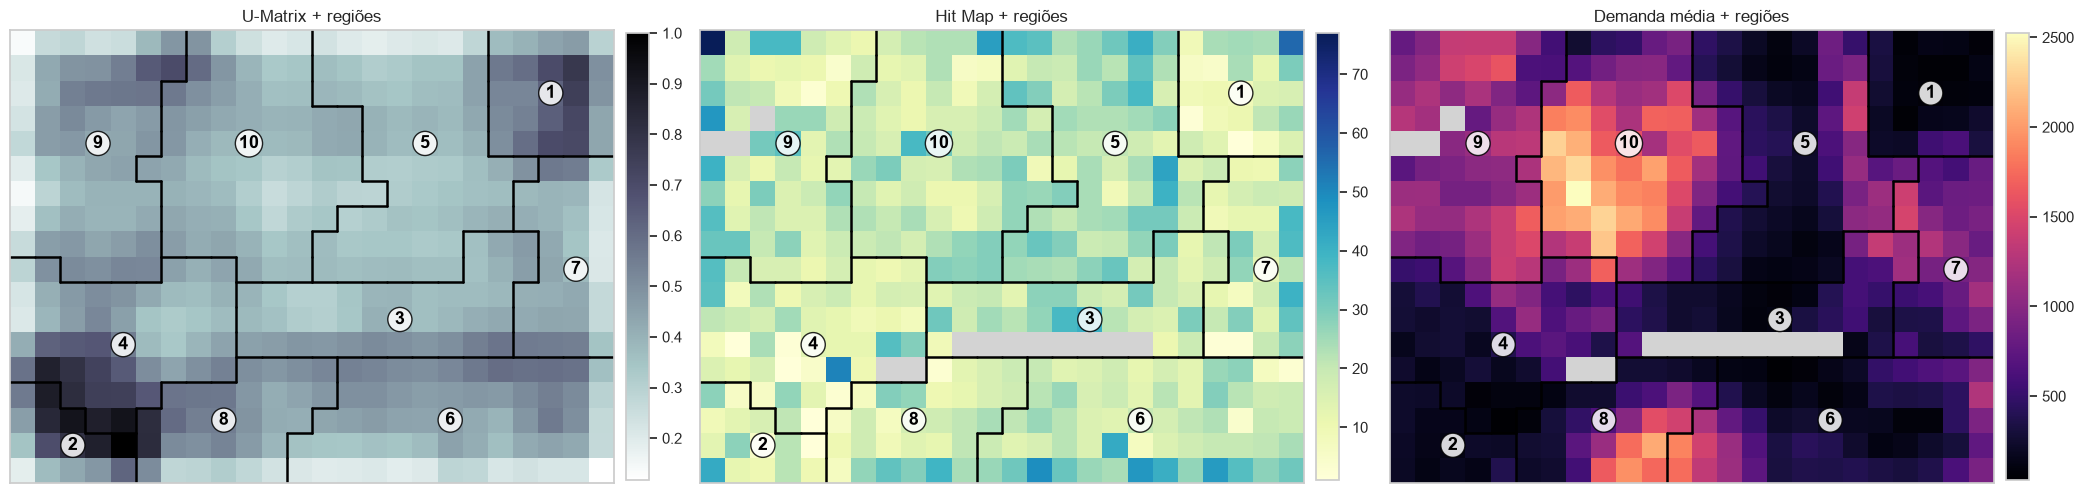

In [14]:
N_REGIONS = 10
region_grid = ward[N_REGIONS].reshape(MAP_X, MAP_Y)
df_map["region"] = region_grid[bmus[:, 0], bmus[:, 1]]

# Numera as regiões pela demanda média, da menor para a maior, para facilitar a leitura
order = df_map.groupby("region")[TARGET].mean().sort_values().index
relabel = {old: new for new, old in enumerate(order, start=1)}
region_grid = np.vectorize(relabel.get)(region_grid)
df_map["region"] = df_map["region"].map(relabel)


def draw_borders(ax, grid, color="black", lw=1.8):
    for i in range(MAP_X):
        for j in range(MAP_Y):
            if i + 1 < MAP_X and grid[i, j] != grid[i + 1, j]:
                ax.plot([i + 1, i + 1], [j, j + 1], color=color, lw=lw)
            if j + 1 < MAP_Y and grid[i, j] != grid[i, j + 1]:
                ax.plot([i, i + 1], [j + 1, j + 1], color=color, lw=lw)


def label_regions(ax, grid, color="black"):
    for r in np.unique(grid):
        ii, jj = np.nonzero(grid == r)
        k = np.argmin((ii - ii.mean()) ** 2 + (jj - jj.mean()) ** 2)
        ax.text(ii[k] + 0.5, jj[k] + 0.5, str(r), ha="center", va="center", fontsize=13, fontweight="bold",
                color=color, bbox=dict(boxstyle="circle,pad=0.2", fc="white", ec=color, alpha=0.85))


fig, axes = plt.subplots(1, 3, figsize=(21, 5))
panels = [(umatrix, "U-Matrix + regiões", "bone_r"),
          (np.where(hits > 0, hits, np.nan), "Hit Map + regiões", "YlGnBu"),
          (per_neuron(df[TARGET]), "Demanda média + regiões", "magma")]
for ax, (values, title, cmap) in zip(axes, panels):
    plot_map(values, ax, title, cmap=cmap)
    draw_borders(ax, region_grid)
    label_regions(ax, region_grid)
plt.tight_layout()
plt.show()

### 5.1 Caracterização das regiões

Estatísticas das **horas reais** associadas aos BMUs de cada região (não dos protótipos). É a etapa de confirmação: o que os mapas de componentes sugerem precisa aparecer nessas contagens.

In [15]:
g = df_map.groupby("region")
region_table = pd.DataFrame({
    "horas": g.size(),
    "% das horas": g.size() / len(df_map) * 100,
    "neurônios": pd.Series(region_grid.ravel()).value_counts().sort_index(),
    "demanda média": g[TARGET].mean(),
    "demanda mediana": g[TARGET].median(),
    "temperatura": g["Temperature(°C)"].mean(),
    "umidade": g["Humidity(%)"].mean(),
    "visibilidade": g["Visibility (10m)"].mean(),
    "radiação solar": g["Solar Radiation (MJ/m2)"].mean(),
    "% com chuva": g["Rainfall(mm)"].apply(lambda s: (s > 0).mean() * 100),
    "% com neve": g["Snowfall (cm)"].apply(lambda s: (s > 0).mean() * 100),
    "% fim de semana": g["IsWeekend"].mean() * 100,
    "% feriado": g["Holiday"].apply(lambda s: s.eq("Holiday").mean() * 100),
})
region_table.round(1)

,horas,% das horas,neurônios,demanda média,demanda mediana,temperatura,umidade,visibilidade,radiação solar,% com chuva,% com neve,% fim de semana,% feriado
1,398,4.7,25,147.7,56.0,17.2,93.0,762.3,0.1,94.7,0.3,19.3,3.5
2,238,2.8,15,191.0,167.5,-1.1,73.3,898.1,0.2,6.3,100.0,25.6,8.8
3,665,7.9,39,400.2,263.0,-2.5,44.4,1779.5,0.2,0.0,1.2,4.5,7.7
4,702,8.3,47,460.5,304.5,-0.7,36.2,1842.9,0.6,0.1,19.1,0.1,7.7
5,1533,18.1,62,481.0,305.0,12.2,72.0,1222.2,0.1,2.2,1.5,0.0,4.3
6,1314,15.5,60,524.0,347.0,11.5,66.6,1231.8,0.1,3.3,1.7,100.0,3.0
7,558,6.6,29,823.9,797.0,18.4,58.4,1339.4,1.2,1.4,0.4,0.4,4.1
8,525,6.2,30,873.8,588.0,9.3,39.9,1844.5,0.6,0.8,1.9,100.0,5.7
9,1199,14.2,59,1081.3,1032.0,23.6,42.4,1597.1,2.2,0.5,0.1,35.9,4.1
10,1333,15.7,66,1378.8,1336.0,19.9,60.5,1515.8,0.2,2.2,0.3,0.1,4.5


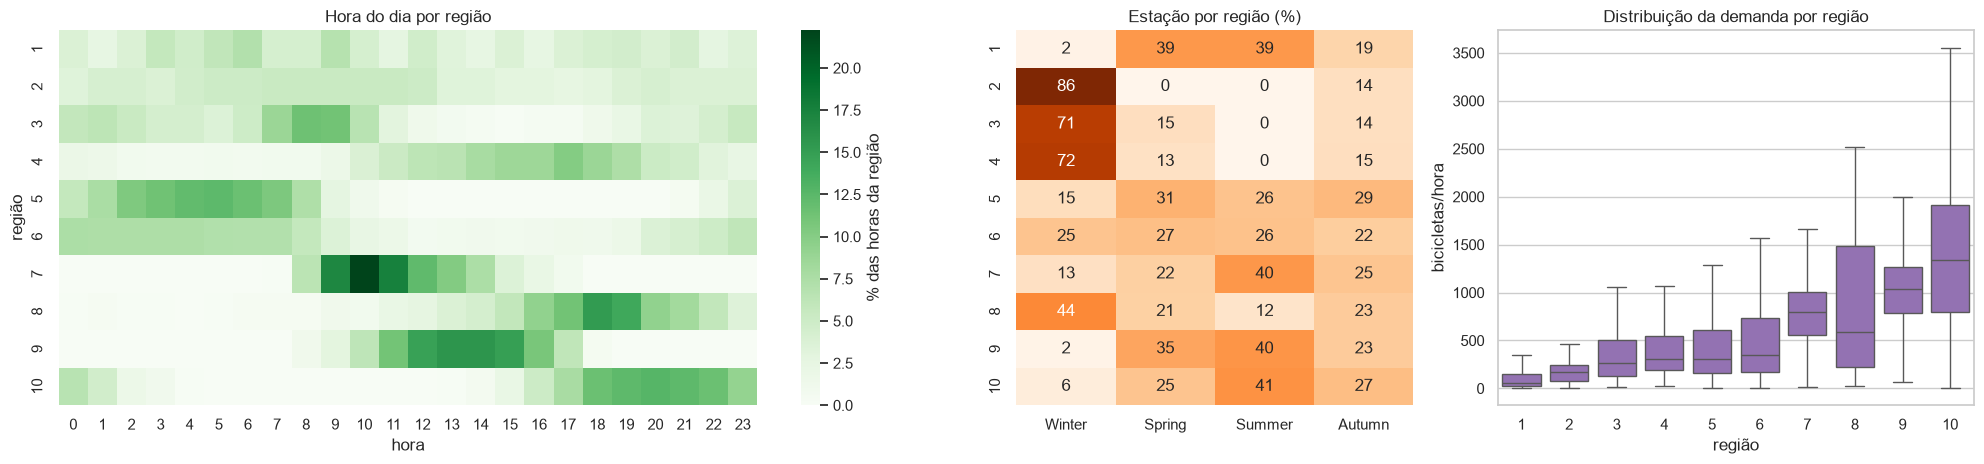

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4.8), gridspec_kw={"width_ratios": [2.2, 1, 1.2]})
hour_mix = pd.crosstab(df_map["region"], df_map["Hour"], normalize="index") * 100
sns.heatmap(hour_mix, cmap="Greens", ax=axes[0], cbar_kws={"label": "% das horas da região"})
axes[0].set(title="Hora do dia por região", xlabel="hora", ylabel="região")
season_mix = pd.crosstab(df_map["region"], df_map["Seasons"], normalize="index")[SEASONS] * 100
sns.heatmap(season_mix, annot=True, fmt=".0f", cmap="Oranges", cbar=False, ax=axes[1])
axes[1].set(title="Estação por região (%)", xlabel="", ylabel="")
sns.boxplot(data=df_map, x="region", y=TARGET, showfliers=False, color="tab:purple", ax=axes[2])
axes[2].set(title="Distribuição da demanda por região", xlabel="região", ylabel="bicicletas/hora")
plt.tight_layout()
plt.show()

### 5.2 Localizar → caracterizar → confirmar

| Região | Localizar (mapa) | Caracterizar (componentes) | Confirmar (horas reais) | Demanda média |
|---|---|---|---|---|
| **1. Chuva** | canto superior direito, crista forte da U-Matrix | chuva, umidade máxima, visibilidade baixa | 95% das horas com chuva, umidade média 93%, qualquer hora do dia | 148 (mediana 56) |
| **2. Neve** | canto inferior esquerdo, crista mais forte do mapa | neve, temperatura negativa | 100% com neve, 86% no inverno | 191 |
| **3. Manhãs e noites de inverno (dia útil)** | centro, logo acima da faixa de fim de semana | frio, seco, visibilidade alta | −2,5 °C, 71% inverno, picos às 7h–9h e 23h–1h | 400 |
| **4. Tardes de inverno (dia útil)** | esquerda, acima da neve | frio, radiação moderada | −0,7 °C, 72% inverno, 14h–19h, 19% com neve residual | 461 |
| **5. Madrugadas de dia útil** | centro-direita da metade superior | hora 2h–7h, sem sol, ameno | 12 °C, sem fim de semana, pico 3h–7h | 481 |
| **6. Noites e madrugadas de fim de semana** | faixa inferior direita | `IsWeekend = 1`, noite | 100% fim de semana, 0h–6h e 20h–23h | 524 |
| **7. Manhãs de dia útil com clima ameno** | borda direita, entre chuva e madrugada | manhã, radiação começando | 18 °C, 9h–13h (máximo às 10h) | 824 |
| **8. Tardes de fim de semana** | faixa inferior esquerda-centro | `IsWeekend = 1`, tarde | 100% fim de semana, 16h–21h, 44% inverno | 874 (mediana 588) |
| **9. Horas de sol forte** | coluna da esquerda | radiação alta, quente, seco | 2,2 MJ/m², 23,6 °C, 11h–16h, 36% fim de semana | 1.081 |
| **10. Fim de tarde e noite de dia útil com clima ameno** | centro da metade superior, núcleo de alta demanda | quente, sem chuva, 18h–23h | 19,9 °C, 0% fim de semana, pico 18h–21h, 41% verão | 1.379 |

**O que as regiões revelam sobre o dataset:**

- **Clima adverso anula a demanda.** Chuva (região 1) e neve (região 2) são os grupos mais isolados do mapa e os de menor demanda, independentemente da hora. A chuva é o fator mais forte: mesmo com temperatura amena (17 °C em média) e ocorrendo em qualquer hora do dia, tem a menor demanda do mapa (mediana de 56 bicicletas/hora).
- **O tipo de dia divide o mapa inteiro.** A faixa de fim de semana é a fronteira mais longa da U-Matrix. Dentro de cada lado, a hora organiza a demanda de forma diferente: nos dias úteis o máximo ocorre no fim de tarde e à noite (região 10, saída do trabalho); no fim de semana, à tarde (região 8).
- **O frio reduz, mas não elimina, a demanda.** As regiões 3 e 4 (inverno seco, dias úteis) ainda têm 400 a 460 bicicletas/hora, mais que o dobro das regiões de chuva e neve: o deslocamento casa-trabalho persiste no frio.
- **Sol e temperatura amena levam a demanda ao máximo.** As regiões 9 e 10 somam 30% das horas e têm as maiores demandas. Na região 9, dias úteis e fins de semana ficam juntos, o que sugere que, com sol forte ao meio-dia, o tipo de dia importa menos que o clima.
- **A região 8 é a mais heterogênea** (caixa mais alta do boxplot, mediana 588 e média 874): reúne tardes de fim de semana frias (44% inverno) e amenas, e a demanda depende muito de qual das duas.
- **Todas as regiões têm pelo menos 238 horas**, então as estatísticas acima não vêm de regiões pouco ocupadas.

## 6. Relação com a MLP: onde o modelo erra?

### 6.1 Reprodução da MLP final

Reconstruímos exatamente o pipeline e a melhor configuração do notebook de MLP (trial 0, comum ao Random Search e ao TPE), com a mesma separação treino/teste por dia e os mesmos 5 folds. Um `assert` garante que o RMSE de teste é o mesmo reportado lá (200,49).

Para ter um erro **fora da amostra** para todas as 8.465 horas, e não só para as 1.704 do teste:

- **horas de teste:** previsão do modelo final, treinado em todo o treino;
- **horas de treino:** previsão *out-of-fold*, feita pelo modelo do fold em que aquela hora estava na validação (treinado nos outros 4 folds).

Assim nenhuma hora é avaliada por um modelo que a viu no treino.

In [17]:
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

MLP_FEATURES = NUMERIC + ["Hour", "IsWeekend", "Seasons", "Holiday"]
BEST = {"n_layers": 2, "n_units": 223, "activation": "relu", "learning_rate": 0.00029380279387035364,
        "batch_size": 128, "solver": "adam", "patience": 30}
N_SPLITS = 5

splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
train_idx, test_idx = next(splitter.split(df, df["Seasons"], groups=df["Date"]))
train_df, test_df = df.iloc[train_idx].reset_index(drop=True), df.iloc[test_idx].reset_index(drop=True)
X_train, y_train = train_df[MLP_FEATURES], train_df[TARGET]
X_test, y_test = test_df[MLP_FEATURES], test_df[TARGET]
cv_splits = list(StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
                 .split(X_train, X_train["Seasons"], train_df["Date"]))


def add_hour_cycle(X):
    X = X.copy()
    X["hour_sin"] = np.sin(2 * np.pi * X["Hour"] / 24)
    X["hour_cos"] = np.cos(2 * np.pi * X["Hour"] / 24)
    return X.drop(columns="Hour")


def build_model(p=BEST, seed=SEED):
    mlp = MLPRegressor(hidden_layer_sizes=(p["n_units"],) * p["n_layers"], activation=p["activation"],
                       solver=p["solver"], learning_rate_init=p["learning_rate"], batch_size=p["batch_size"],
                       early_stopping=True, n_iter_no_change=p["patience"], max_iter=300, random_state=seed)
    prep = ColumnTransformer([
        ("num", StandardScaler(), NUMERIC),
        ("cat", OneHotEncoder(drop="if_binary"), ["Seasons", "Holiday"]),
        ("pass", "passthrough", ["IsWeekend", "hour_sin", "hour_cos"]),
    ])
    pipeline = Pipeline([("hour", FunctionTransformer(add_hour_cycle)), ("prep", prep), ("mlp", mlp)])
    return TransformedTargetRegressor(regressor=pipeline, func=np.sqrt, inverse_func=np.square, check_inverse=False)


final_model = build_model().fit(X_train, y_train)
test_pred = final_model.predict(X_test)
test_rmse = float(np.sqrt(mean_squared_error(y_test, test_pred)))
print(f"Teste: RMSE {test_rmse:.2f} | MAE {mean_absolute_error(y_test, test_pred):.2f} | R² {r2_score(y_test, test_pred):.3f}")
assert abs(test_rmse - 200.49) < 0.01, "a MLP reproduzida difere da do notebook de MLP"

oof_pred = cross_val_predict(build_model(), X_train, y_train, cv=cv_splits, n_jobs=N_SPLITS)
print(f"Out-of-fold no treino: RMSE {np.sqrt(mean_squared_error(y_train, oof_pred)):.2f} | "
      f"MAE {mean_absolute_error(y_train, oof_pred):.2f}")

Teste: RMSE 200.49 | MAE 122.90 | R² 0.905


Out-of-fold no treino: RMSE 185.85 | MAE 115.63


In [18]:
pred = np.empty(len(df))
pred[train_idx], pred[test_idx] = oof_pred, test_pred
df_map["origem"] = "treino (out-of-fold)"
df_map.loc[test_idx, "origem"] = "teste"
df_map["previsto"] = pred
df_map["erro"] = df_map["previsto"] - df_map[TARGET]          # positivo = superestima
df_map["erro absoluto"] = df_map["erro"].abs()
print(f"MAE global fora da amostra: {df_map['erro absoluto'].mean():.1f} bicicletas/hora")

MAE global fora da amostra: 117.1 bicicletas/hora


### 6.2 Erro da MLP por BMU

Neurônios com poucas horas têm médias instáveis. Por isso, os mapas de erro só mostram neurônios com **pelo menos 10 horas** (os demais ficam em cinza). Além do MAE absoluto, mostramos o **viés** (erro médio com sinal, previsto − real) e o **MAE relativo** (MAE dividido pela demanda média do neurônio), porque o erro absoluto tende a crescer com a própria demanda.

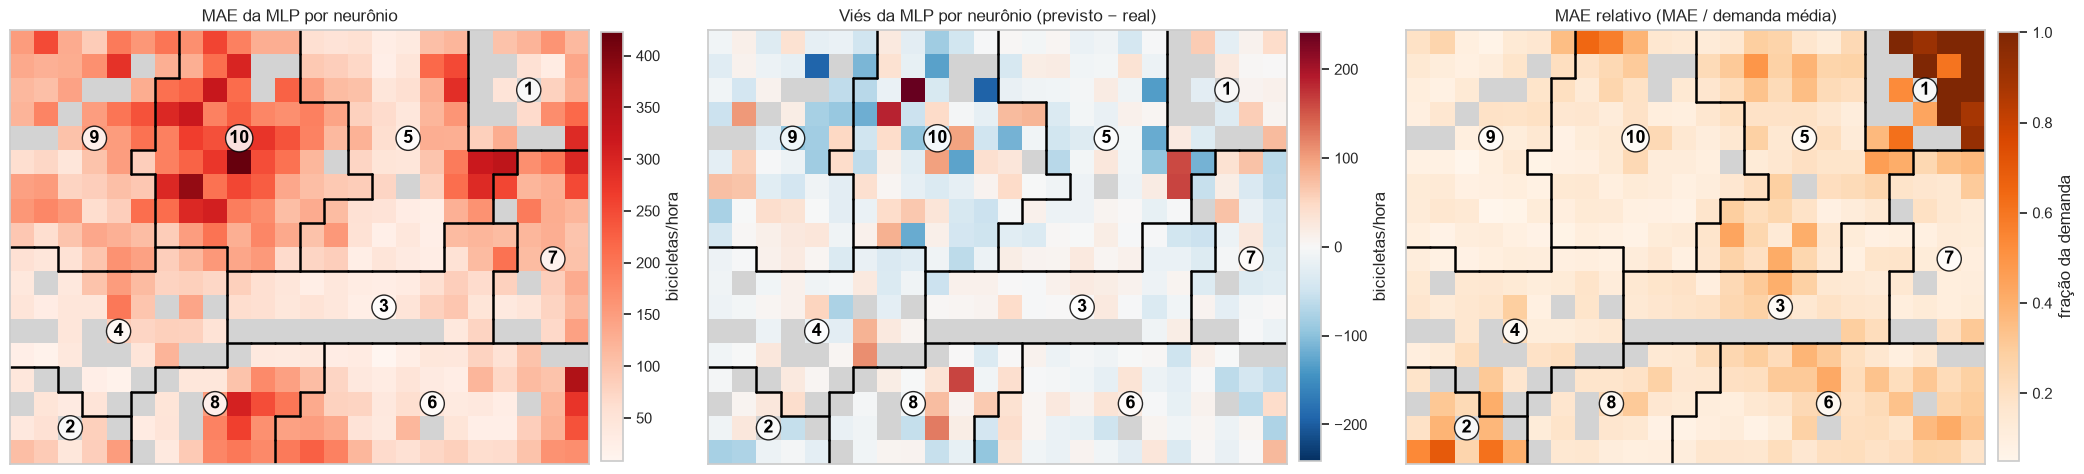

Neurônios com ≥ 10 horas: 372 de 432 (96.7% das horas)
Correlação por neurônio entre MAE e demanda média: 0.73
Correlação por neurônio entre MAE e desvio padrão da demanda: 0.78


In [19]:
MIN_HITS = 10
mae_grid = per_neuron(df_map["erro absoluto"], "mean", MIN_HITS)
bias_grid = per_neuron(df_map["erro"], "mean", MIN_HITS)
rel_grid = mae_grid / per_neuron(df[TARGET], "mean", MIN_HITS)
lim = np.nanmax(np.abs(bias_grid))

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for ax, (values, title, cmap, label, kw) in zip(axes, [
        (mae_grid, "MAE da MLP por neurônio", "Reds", "bicicletas/hora", {}),
        (bias_grid, "Viés da MLP por neurônio (previsto − real)", "RdBu_r", "bicicletas/hora", {"vmin": -lim, "vmax": lim}),
        (rel_grid, "MAE relativo (MAE / demanda média)", "Oranges", "fração da demanda", {"vmax": 1})]):
    plot_map(values, ax, title, cmap=cmap, label=label, **kw)
    draw_borders(ax, region_grid)
    label_regions(ax, region_grid)
plt.tight_layout()
plt.show()

valid = ~np.isnan(mae_grid)
print(f"Neurônios com ≥ {MIN_HITS} horas: {valid.sum()} de {valid.size} ({hits[valid].sum() / hits.sum():.1%} das horas)")
std_grid = per_neuron(df[TARGET], "std", MIN_HITS)
print(f"Correlação por neurônio entre MAE e demanda média: "
      f"{np.corrcoef(per_neuron(df[TARGET], 'mean', MIN_HITS)[valid], mae_grid[valid])[0, 1]:.2f}")
print(f"Correlação por neurônio entre MAE e desvio padrão da demanda: {np.corrcoef(std_grid[valid], mae_grid[valid])[0, 1]:.2f}")

In [20]:
g = df_map.groupby("region")
gt = df_map[df_map["origem"] == "teste"].groupby("region")
df_map["desvio no neurônio"] = df_map.groupby(["bmu_x", "bmu_y"])[TARGET].transform("std")
error_table = pd.DataFrame({
    "horas": g.size(),
    "demanda média": g[TARGET].mean(),
    "desvio da demanda no neurônio": g["desvio no neurônio"].mean(),
    "MAE": g["erro absoluto"].mean(),
    "RMSE": g["erro"].apply(lambda e: np.sqrt((e ** 2).mean())),
    "MAE relativo": g["erro absoluto"].mean() / g[TARGET].mean(),
    "viés": g["erro"].mean(),
    "% das horas": g.size() / len(df_map) * 100,
    "% do erro absoluto total": g["erro absoluto"].sum() / df_map["erro absoluto"].sum() * 100,
    "horas de teste": gt.size(),
    "MAE só no teste": gt["erro absoluto"].mean(),
})
error_table.round(2)

,horas,demanda média,desvio da demanda no neurônio,MAE,RMSE,MAE relativo,viés,% das horas,% do erro absoluto total,horas de teste,MAE só no teste
region,,,,,,,,,,,
1,398,147.70,188.08,130.19,208.92,0.88,12.21,4.70,5.23,108,99.33
2,238,190.97,129.41,70.01,109.80,0.37,-20.63,2.81,1.68,56,41.38
3,665,400.16,241.42,62.70,107.48,0.16,-1.52,7.86,4.21,109,55.33
4,702,460.50,247.67,66.14,106.15,0.14,2.36,8.29,4.68,130,67.27
5,1533,481.01,269.74,100.26,172.95,0.21,-7.35,18.11,15.51,281,108.38
6,1314,523.99,230.13,97.72,159.39,0.19,-7.10,15.52,12.95,284,105.96
7,558,823.86,327.14,127.45,187.39,0.15,-16.50,6.59,7.17,131,155.06
8,525,873.80,318.90,122.01,203.80,0.14,6.37,6.20,6.46,112,141.12
9,1199,1081.27,329.22,133.56,189.23,0.12,-15.27,14.16,16.16,227,145.72


### 6.3 Discussão: os erros da MLP se concentram em regiões?

**Sim, e de forma coerente com a estrutura encontrada pela SOM.**

- **O erro absoluto cresce com a demanda.** A correlação entre MAE e demanda média por neurônio é 0,73. A região 10 (fim de tarde e noite de dia útil) tem só 15,7% das horas, mas **26% de todo o erro absoluto** da MLP (MAE 193). As regiões de sol (9) e de manhã (7) vêm em seguida. Isso reproduz, por outro caminho, o que o notebook de MLP mostrou pelo erro por hora (máximo às 8h e às 18h).
- **O erro acompanha ainda mais a variabilidade da demanda.** A correlação entre MAE e desvio padrão da demanda no neurônio é **0,78**, maior que com a própria demanda. Nas horas da região 10, o desvio padrão da demanda dentro do mesmo neurônio é de 459 bicicletas/hora: horas com clima, hora e tipo de dia quase iguais têm demandas muito diferentes. A MLP reduz bastante essa incerteza (MAE 193, graças também a `Seasons`, `Holiday` e às relações não lineares), mas o que sobra é, em grande parte, variação que **os atributos disponíveis não explicam**, possivelmente ligada a fatores ausentes do dataset (tendência de uso ao longo do ano, eventos, particularidades de cada dia).
- **Em termos relativos, a chuva é o ponto fraco.** Na região 1 o MAE (130) é **88% da demanda média** (148), contra 12% a 21% nas demais regiões. O modelo erra pouco em bicicletas, mas quase nada acerta em proporção. Três fatores explicam: a chuva ocupa só 4,7% das horas, a demanda na chuva é muito dispersa (mediana 56, média 148), e na MLP a chuva entrou apenas padronizada, com 94% de zeros e alguns valores extremos.
- **Viés:** nas regiões de alta demanda (7, 9 e 10) a MLP **subestima** em média (viés de −13 a −17 bicicletas/hora), o mesmo padrão visto no gráfico previsto × real do notebook de MLP. Na chuva ela superestima levemente (+12). Neurônios isolados com viés forte no mapa (em vermelho ou azul intenso) têm poucas horas e não devem ser interpretados individualmente.
- **Regiões fáceis:** inverno seco em dia útil (regiões 3 e 4, MAE 63 a 66) e neve (região 2, MAE 70): demanda baixa e regular.
- **O padrão se mantém no teste.** Considerando só as 1.704 horas de teste, a ordem é a mesma: a região 10 tem o maior MAE (195) e a região 2 o menor (41). Como cada região tem pelo menos 56 horas de teste, a conclusão não depende de regiões pouco ocupadas.

**Implicações para a MLP.** A SOM aponta melhorias concretas que o trabalho de MLP não testou: aplicar `log1p` ou criar um indicador binário para chuva e neve, incluir chuva nas horas anteriores (a demanda pode continuar baixa depois que a chuva para) e adicionar variáveis de calendário que a estação não captura (mês ou tendência ao longo do ano). Também sugere avaliar o modelo por região: um RMSE global de ~200 esconde um erro relativo de 88% nas horas de chuva.

## 7. Conclusões da equipe

- **Configuração:** uma SOM 24 × 18 treinada com 10 atributos de clima, hora e tipo de dia (sem o alvo), com `sigma = 3`, obteve erro de quantização de 1,10 e erro topográfico de 4,7%: representa bem os dados e preserva a vizinhança, o que torna confiável a leitura por regiões.
- **Estrutura dos dados:** as horas formam um contínuo organizado por três eixos: **tipo de dia** (a fronteira mais longa do mapa), **temperatura/estação** e **hora do dia**. Chuva e neve formam os únicos grupos realmente isolados.
- **Relação com a demanda:** sem ver o alvo, o mapa separou horas de demanda muito baixa (chuva, neve, madrugada) das de demanda máxima (fim de tarde de dia útil com clima ameno e horas de sol forte). Isso confirma que os atributos escolhidos para a MLP carregam a maior parte da informação sobre a demanda.
- **Sazonalidade:** inverno e verão são recuperados pelo clima, mas **primavera e outono são indistinguíveis** nas condições da hora. Isso justifica manter `Seasons` como entrada explícita da MLP.
- **Relação com a MLP:** os erros se concentram nas regiões de maior demanda e, principalmente, de maior variabilidade (região 10: 16% das horas e 26% do erro). Em termos relativos, a MLP é fraca nas horas de chuva (erro de 88% da demanda média). Os resultados se mantêm no conjunto de teste.
- **Próximos passos para a MLP:** tratar chuva e neve com `log1p` ou indicadores, incluir chuva defasada e variáveis de calendário, e reportar o erro por região além do RMSE global.
- **Limitações:** uma única semente para a SOM; regiões definidas por um agrupamento auxiliar com silhueta baixa (são uma partição para interpretação, não grupos naturais); conclusões por neurônio limitadas aos neurônios com pelo menos 10 horas.